# Unsupervised model

## Preparation of the data

Import the dependences

In [1]:
# !pip install cesnet-datazoo

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from cesnet_datazoo.datasets import CESNET_QUICEXT_25
from cesnet_datazoo.config import DatasetConfig, AppSelection

Load the data

In [2]:
unsupervised_dataset = CESNET_QUICEXT_25("~/datasets/CESNET-QUICEXT-25/", size="XS")
dataset_config = DatasetConfig(
    dataset=unsupervised_dataset,
    apps_selection=AppSelection.ALL_KNOWN,
    train_period_name="W-2024-22",
    test_period_name="W-2025-22",
)
unsupervised_dataset.set_dataset_config_and_initialize(dataset_config)
unsupervised_dataset = unsupervised_dataset.get_test_df()

unsupervised_dataset.head()

Loading data from dataloader


100%|██████████| 10/10 [00:03<00:00,  2.64it/s]


,PPI,BYTES,BYTES_REV,PACKETS,PACKETS_REV,DURATION,PPI_LEN,PPI_ROUNDTRIPS,PPI_DURATION,FLOW_ENDREASON_IDLE,FLOW_ENDREASON_ACTIVE,FLOW_ENDREASON_OTHER,APP
0,"[[0.0, 5.0, 12.0, 0.0, 2.0, 0.0, 1.0, 2.0, 0.0...",7137.0,7187.0,14.0,15.0,4.082915,29.0,6.0,4.083,1.0,0.0,0.0,0
1,"[[0.0, 1.0, 0.0, 0.0, 7.0, 0.0, 0.0, 0.0, 0.0,...",337586.0,409540.0,384.0,463.0,299.559448,30.0,5.0,0.135,0.0,1.0,0.0,2
2,"[[0.0, 5003.0, 5002.0, 0.0, 5.0, 0.0, 4997.0, ...",7368.0,2456.0,6.0,2.0,15.011243,8.0,2.0,15.011,1.0,0.0,0.0,0
3,"[[0.0, 1.0, 0.0, 0.0, 13.0, 0.0, 0.0, 0.0, 0.0...",8957.0,10049.0,18.0,22.0,3.108871,30.0,9.0,0.199,1.0,0.0,0.0,2
4,"[[0.0, 2.0, 0.0, 0.0, 94.0, 0.0, 18.0, 0.0, 0....",7680.0,20607.0,6.0,32.0,25.601650,30.0,6.0,6.369,1.0,0.0,0.0,2


Data cleaning + feature engineering

In [3]:
# Delete spaces
unsupervised_dataset.columns = unsupervised_dataset.columns.str.strip()

# Calculate Total Bytes and Total Packets
unsupervised_dataset["TotalBytes"]   = unsupervised_dataset["BYTES"] + unsupervised_dataset["BYTES_REV"]
unsupervised_dataset["TotalPackets"] = unsupervised_dataset["PACKETS"] + unsupervised_dataset["PACKETS_REV"]

# Calculate FlowBytesPerSec, FlowPacketsPerSec and AveragePacketSize
unsupervised_dataset["FlowBytesPerSec"]   = unsupervised_dataset["TotalBytes"] / unsupervised_dataset["DURATION"]
unsupervised_dataset["FlowPacketsPerSec"] = unsupervised_dataset["TotalPackets"] / unsupervised_dataset["DURATION"]
unsupervised_dataset["AveragePacketSize"] = unsupervised_dataset["TotalBytes"] / unsupervised_dataset["TotalPackets"]

# Rename variable
unsupervised_dataset = unsupervised_dataset.rename(columns={"DURATION": "FlowDuration"})

# Keep only the variable in common between the two datasets
features = [
    "FlowDuration",
    "TotalPackets",
    "TotalBytes",
    "FlowBytesPerSec",
    "FlowPacketsPerSec",
    "AveragePacketSize",
]
unsupervised_dataset = unsupervised_dataset[features]

# Cleaning
unsupervised_dataset = unsupervised_dataset[unsupervised_dataset["FlowDuration"] > 0]
unsupervised_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
unsupervised_dataset.dropna(inplace=True)

print("shape after cleaning : ", unsupervised_dataset.shape)

shape after cleaning :  (19235, 6)


Load captured dataset

In [4]:
# Load the data
capture_ai_heavy = pd.read_csv("data/capture_ai_heavy_2.csv")
capture_ai_leger = pd.read_csv("data/capture_normal_ai_2.csv")
capture_cloud_work = pd.read_csv("data/capture_cloud_work_2.csv")
capture_normal_web= pd.read_csv("data/capture_normal_web_2.csv")
capture_streaming= pd.read_csv("data/capture_streaming_2.csv")

capture_ai_claude = pd.read_csv("data/capture_ai_claude.csv")
capture_ai_gemini_chatty = pd.read_csv("data/capture_ai_gemini_chatty.csv")
capture_metro = pd.read_csv("data/capture_metro.csv")
capture_youtube = pd.read_csv("data/capture_youtube.csv")

capture_ai_image = pd.read_csv("data/capture_ai_image.csv")
capture_ai = pd.read_csv("data/capture_ai.csv")
capture_classic_web = pd.read_csv("data/capture_classic_web.csv")
capture_streaming_3 = pd.read_csv("data/capture_streaming_3.csv")

# labelisation
normal = pd.concat([capture_cloud_work, capture_normal_web, capture_streaming, capture_metro, capture_youtube, capture_classic_web, capture_streaming_3])
ai = pd.concat([capture_ai_heavy, capture_ai_leger, capture_ai_claude, capture_ai_gemini_chatty, capture_ai_image, capture_ai])

normal["label_ia"] = 0
ai["label_ia"] = 1

supervised_dataset = pd.concat([normal, ai], ignore_index=True)
supervised_dataset.shape

# delete space at the begining/end of the columns 
supervised_dataset.columns = supervised_dataset.columns.str.strip()

# Calculate of FlowBytesPerSec, FlowPacketsPerSec, AveragePacketSize
supervised_dataset["FlowBytesPerSec"] = supervised_dataset["TotBytes"] / supervised_dataset["Dur"]
supervised_dataset["FlowPacketsPerSec"] = supervised_dataset["TotPkts"] / supervised_dataset["Dur"]
supervised_dataset["AveragePacketSize"] = supervised_dataset["TotBytes"] / supervised_dataset["TotPkts"]

# Rename
supervised_dataset = supervised_dataset.rename(
    columns={
        "Dur":"FlowDuration",
        "Proto":"Protocol",
        "Dport":"DestinationPort",
        "TotPkts":"TotalPackets",
        "TotBytes":"TotalBytes",
        "State":"ConnectionState",
        "Dir":"Direction",
        "label_ia":"LabelAI"
    }
)

# Keep only the columns that we need
features = [
    "FlowDuration",
    "DestinationPort",
    "TotalPackets",
    "TotalBytes",
    "FlowBytesPerSec",
    "FlowPacketsPerSec",
    "AveragePacketSize",
    "LabelAI"
] 
supervised_dataset = supervised_dataset[features]

# Avoid division by 0
supervised_dataset = supervised_dataset[supervised_dataset["FlowDuration"] >= 0]
supervised_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
supervised_dataset.dropna(inplace=True)

# Uniformisation of the ports
supervised_dataset["DestinationPort"] = supervised_dataset["DestinationPort"].replace({
    "https":   443,
    "http":    80,
    "domain":  53,
    "dns":     53,
    "ntp":     123,
    "ssh":     22,
    "ftp":     21,
    "smtp":    25,
    "imap":    143,
    "pop3":    110,
    "ldap":    389,
    "snmp":    161,
    "quic":    443,
    "mdns":    5353,
})

# Train / test / validation 
supervised_train, temporary_subset = train_test_split(supervised_dataset, test_size=0.4, random_state=42)
supervised_validation, supervised_test = train_test_split(temporary_subset, test_size=0.5, random_state=42)

## Unsupervised model

Data normalization: normalization of the CESNET DataZoo dataset and normalization of our controlled dataset in the same feature space.

In [5]:
features = [
    "FlowDuration",
    "TotalPackets",
    "TotalBytes",
    "FlowBytesPerSec",
    "FlowPacketsPerSec",
    "AveragePacketSize",
]

scaler = StandardScaler()

# CESNET Datazoo
X_train_scaled = scaler.fit_transform(unsupervised_dataset) 

# Controlled dataset
X_controlled_dataset = supervised_train[features].copy()
y_controlled_dataset = supervised_train["LabelAI"]
X_controlled_dataset_scaled = scaler.transform(X_controlled_dataset)

### K-means et DBSCAN

The first step we are going to apply is dimensionality reduction using PCA then t-SNE to visualise the data.

Cumulative explained variance (PCA): [0.40109938 0.7180384  0.8718826  0.9939514  0.99989927 0.99999994]


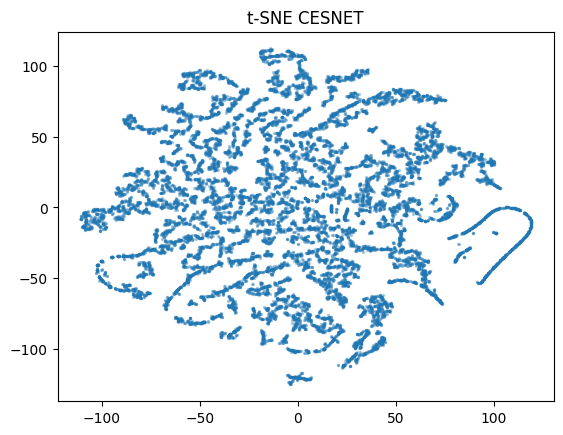

In [6]:
# Principal Component Analysis 
pca = PCA(n_components=6, random_state=42)  
X_pca = pca.fit_transform(X_train_scaled)
print("Cumulative explained variance (PCA):", pca.explained_variance_ratio_.cumsum())

# T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)  

# Ploting the data
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=2, alpha=0.3)
plt.title("t-SNE CESNET")
plt.show()

We then tune the parameters using k-means :

In [12]:
# K-means
inertias = []
silhouettes = []
calinski = []

results = []

for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette": silhouette_score(X_pca, labels, sample_size=5000),
        "Calinski-Harabasz": calinski_harabasz_score(X_pca, labels),
    })

pd.DataFrame(results)

,k,Inertia,Silhouette,Calinski-Harabasz
0,2,83687.164062,0.873199,7290.548828
1,3,68288.984375,0.440186,6635.272949
2,4,54724.535156,0.418869,7108.595703
3,5,40655.074219,0.483117,8839.856445


We can visualize the clusters produced by K-means on the t-SNE projection using the best hyperparameter settings :

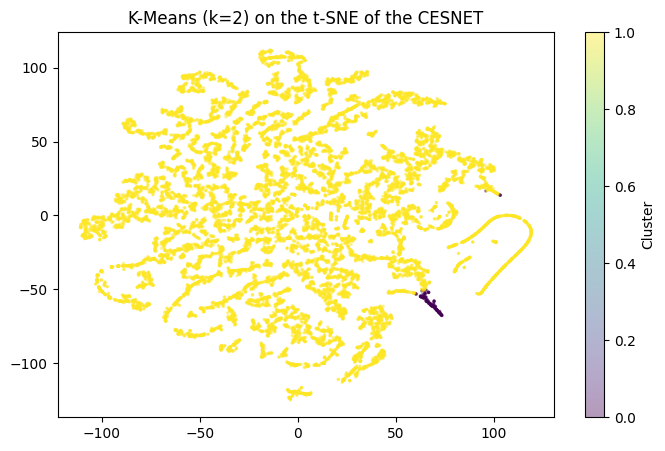

In [13]:
kmeans_best = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_best = kmeans_best.fit_predict(X_pca)

plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_best, s=2, alpha=0.4)
plt.title(f"K-Means (k=2) on the t-SNE of the CESNET")
plt.colorbar(label="Cluster")
plt.show()

Validating and obtaining metrics on the dataset that we captured ourselves and which is labeled.

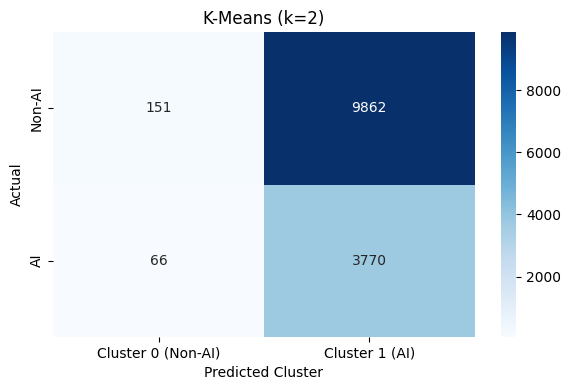

              precision    recall  f1-score   support

           0       0.70      0.02      0.03     10013
           1       0.28      0.98      0.43      3836

    accuracy                           0.28     13849
   macro avg       0.49      0.50      0.23     13849
weighted avg       0.58      0.28      0.14     13849



In [37]:
# Projecting the captured dataset on the PCA of the CESNET Datazoo
X_controlled_dataset_pca = pca.transform(X_controlled_dataset_scaled)
X_pca = X_pca.astype(np.float64)
X_controlled_dataset_pca = X_controlled_dataset_pca.astype(np.float64)

# Applying k-means with the best hyperparameters we found
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
km_final.fit(X_pca)  # fit on CESNET
wifi_clusters = km_final.predict(X_controlled_dataset_pca)

# Confusion matrix
cm = confusion_matrix(y_controlled_dataset, wifi_clusters)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Cluster 0 (Non-AI)", "Cluster 1 (AI)"], yticklabels=["Non-AI", "AI"])
plt.title("K-Means (k=2)")
plt.xlabel("Predicted Cluster")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_controlled_dataset, wifi_clusters))

## Isolation forest

We first tune the hyperparameters of the Isolation Forest model with the validation of the controlled dataset.

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "contamination": [0.005, 0.01, 0.02, 0.05],
    "max_features": [0.5, 0.75, 1.0],
}

results = []

# Each combination possible of n_estimators, contamination & max_features
for n_estimator in param_grid["n_estimators"]:
    for contamination in param_grid["contamination"]:
        for max_feature in param_grid["max_features"]:
            isolationForest = IsolationForest(n_estimators=n_estimator,contamination=contamination, max_features=max_feature, random_state=42, n_jobs=-1)
            isolationForest.fit(X_train_scaled)
            
            # Evaluate on the controlled dataset
            controlled_dataset_predictions = isolationForest.predict(X_controlled_dataset_scaled)
            controlled_dataset_binary = (controlled_dataset_predictions == -1).astype(int)
            f1 = f1_score(y_controlled_dataset, controlled_dataset_binary, pos_label=1, zero_division=0)
            
            results.append({
                "n_estimators": n_estimator,
                "contamination": contamination,
                "max_features": max_feature,
                "f1_ai": f1,
            })

results_df = pd.DataFrame(results).sort_values("f1_ai", ascending=False)
results_df.head(10)

,n_estimators,contamination,max_features,f1_ai
10,100,0.05,0.75,0.142152
22,200,0.05,0.75,0.141139
23,200,0.05,1.00,0.139849
11,100,0.05,1.00,0.137490
21,200,0.05,0.50,0.135911
9,100,0.05,0.50,0.131378
20,200,0.02,1.00,0.090051
8,100,0.02,1.00,0.087321
19,200,0.02,0.75,0.081551
6,100,0.02,0.50,0.075798


We can then visualize the best parameters we found earlier through the distribution of anomaly scores (lower = more abnormal).

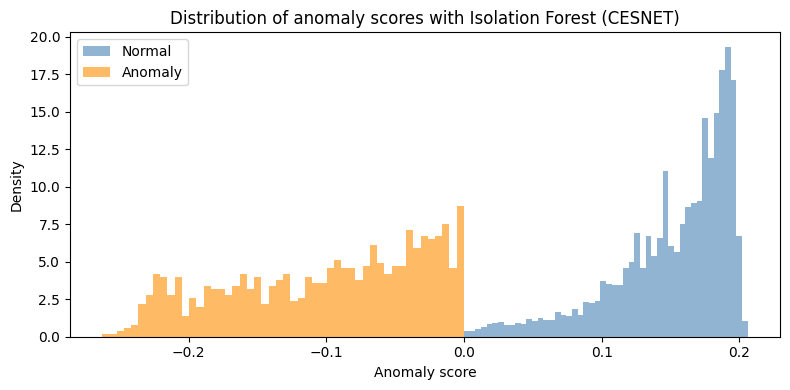

In [30]:
# Recalculer avec le modèle final tunné
scores = model.decision_function(X_train_scaled)
predictions = model.predict(X_train_scaled)

plt.figure(figsize=(8, 4))
plt.hist(scores[predictions == 1],  bins=50, alpha=0.6, color="steelblue",  label="Normal",  density=True)
plt.hist(scores[predictions == -1], bins=50, alpha=0.6, color="darkorange", label="Anomaly", density=True)
plt.title("Distribution of anomaly scores with Isolation Forest (CESNET)")
plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

We then fit the Isolation Forest model on the CESNET DataZoo dataset and use it to make predictions on the dataset we captured ourselves to evaluate its performance.

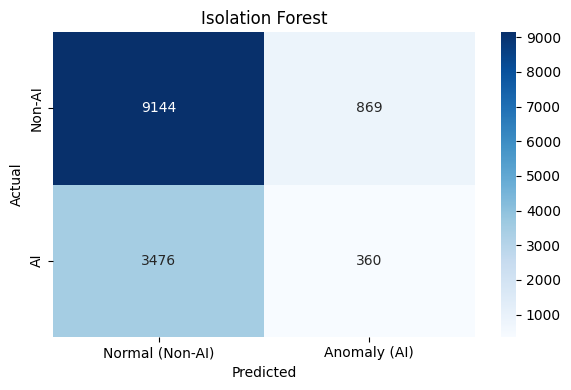

              precision    recall  f1-score   support

           0       0.72      0.91      0.81     10013
           1       0.29      0.09      0.14      3836

    accuracy                           0.69     13849
   macro avg       0.51      0.50      0.48     13849
weighted avg       0.61      0.69      0.62     13849



In [ ]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    max_features=0.75,
    random_state=42,
    n_jobs=-1,
)

# Fit on the CESNET Datazoo
model.fit(X_train_scaled)

# Make predictions with this model on the controlled dataset
controlled_dataset_predictions = model.predict(X_controlled_dataset_scaled)
controlled_dataset_binary = (controlled_dataset_predictions == -1).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_controlled_dataset, controlled_dataset_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal (Non-AI)", "Anomaly (AI)"], yticklabels=["Non-AI", "AI"])
plt.title("Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_controlled_dataset, controlled_dataset_binary))